(setting-chamber)=
# 稳定段优化设计

**作者**: 裴海涛, 陈吉明, 廖达雄, 朱博, 吴盛豪

**摘要**: 气流湍流特性是衡量风洞流场水平的一个重要指标, 也是影响模型动态测量数据精准性的关键参数。针对0.6 m连续式跨声速风洞, 依托2种计算方法搭建了连续式风洞整流装置湍流计算模型, 给出了2种方法的湍流度计算结果, 并与实际测试结果进行了比较。分析发现, 2种方法获得的气流湍流衰减变化趋势基本一致, 湍流度衰减主要集中在前3层阻尼网, 衰减约65%;方法一较实测最大值偏大约21%, 方法二与实测最小值更为接近, 虽然2种方法所得结果与实测值绝对值稍有偏差, 但趋势及结果量级一致, 因此可有效用于风洞整流装置优化设计。

**关键词**: 连续式跨声速风洞; 气流湍流度; 阻尼网; 优化设计

## 1 设备概况
中国空气动力研究与发展中心的0.6 m连续式跨声速试验设备，试验段截面宽和高均为0.6 m，试验气流马赫数为0.2~1.6，风洞试验段气流湍流度要求为0.05%~0.25%(*Ma*≤1.0)，稳定段内设置有1个蜂窝器和5层阻尼网安装位置。

## 2 风洞气流湍流度计算方法
连续式风洞气流湍流度计算物理模型，通常从稳定段的蜂窝器入口开始，顺气流依次经过阻尼网、静流段及收缩段，推算至试验段，如 **图 1** 所示。国内外各种计算方法主要采用通过大量试验得到的经验公式，如Refai Ahmed等针对阻尼网试验研究了开孔率及其布置位置等对湍流度的影响情况，并给出了阻尼网对湍流度影响的经验公式。本文介绍其中的2种计算方法，这2种方法在物理模型的选取上有较大差异，各自独具优点，具体在方法介绍中阐述。

![图 1 风洞稳定段至试验段轮廓示意图](imgs/xbgydxxb-41-1-216-1.jpg)

### 2.1 气流湍流度
湍流度是气流的速度脉动，是由于流体微团的无规则运动而形成的。高空静止大气的湍流度约为0.03%。湍流度是指气流中3个方向的脉动气流速度的方根平均值与主流平均速度之比，气流总湍流强度的表达式见公式(1)，3个方向上的分量表达式见公式(2)。

$$
Tu = \frac{\sqrt{\frac{1}{3}(\overline{u'^2} + \overline{v'^2} + \overline{w'^2})}}{U}
\quad(1)
$$

$$
Tu_u = \frac{\sqrt{\overline{u'^2}}}{U}, \quad Tu_v = \frac{\sqrt{\overline{v'^2}}}{U}, \quad Tu_w = \frac{\sqrt{\overline{w'^2}}}{U}
\quad(2)
$$

式中: $u′$, $v′$, $w′$为湍流脉动在3个方向上的速度分量; $U$为气流流向平均速度。

由于速度脉动属于流场动态特性参数，受气流温度、压力波动等复杂因素影响，其测试及数据分析处理难度大。在风洞中，通常采用热线风速仪测量气流湍流度，对于超声速风洞也可采用非接触光学测量方法。其设计计算通常采用工程经验方法进行。本文以气流纵向湍流为例，介绍相关计算方法。

### 2.2 方法一
本方法的计算物理模型如 **图 2** 所示。假定气流流经风洞内蜂窝器及阻尼网等堵塞部件后，气流湍流度一方面会由于摩擦作用及前后压降而衰减，另一方面也会因为气流流经堵塞部件后而新产生湍流；气流流经收缩段时，气流湍流度仅发生衰减。具体计算公式见 **表 1**，表中所列公式为基于风洞试验得到的经验公式。

![图 2 方法一计算物理模型](imgs/xbgydxxb-41-1-216-2.jpg)

**表 1 方法一气流湍流度计算方法**

| 部段 | 衰减后的湍流度 | 新增湍流度 | 总湍流度 |
| :--- | :--- | :--- | :--- |
| 蜂窝器 | $Tu_{hc_1}=1.3 \cdot Tu_{hc_{in}} \cdot \Psi_{ley}$ | $Tu_{hc_2} = \sqrt{0.0015 \cdot (\frac{L_{hc}}{d_{hc}})^{-0.4}}$ | $Tu_{hc_{out}} = \sqrt{Tu_{hc_1}^2 + Tu_{hc_2}^2}$ |
| 阻尼网 | $Tu_{s_1} = \frac{Tu_{s_{in}}}{\sqrt{1+K}}$ | $Tu_{s_2} = \sqrt{\frac{0.75}{1+K}}$ | $Tu_{s_{out}} = \sqrt{Tu_{s_1}^2 + Tu_{s_2}^2}$ |
| 收缩段 | $Tu_{u_c} = \sqrt{Tu_{u_{in}}^2 \cdot C^{-2} + Tu_{v_{in}}^2 \cdot \frac{1}{2}C(1 - \frac{\ln(4C^3)}{2(C^3-1)})}$ | | |

In [1]:
import numpy as np

def method1_honeycomb(Tu_in, L_hc, d_hc, Psi_ley=1.0):
    """
    Calculates turbulence intensity after honeycomb using Method 1.
    
    Args:
        Tu_in (float): Incoming turbulence intensity.
        L_hc (float): Length of honeycomb.
        d_hc (float): Diameter of honeycomb cell.
        Psi_ley (float): Ley's factor (default 1.0).
        
    Returns:
        float: Turbulence intensity after honeycomb.
    """
    Tu_hc_1 = 1.3 * Tu_in * Psi_ley
    Tu_hc_2 = np.sqrt(0.0015 * (L_hc / d_hc)**(-0.4))
    Tu_hc_out = np.sqrt(Tu_hc_1**2 + Tu_hc_2**2)
    return Tu_hc_out

def method1_screen(Tu_in, K):
    """
    Calculates turbulence intensity after a screen using Method 1.
    
    Args:
        Tu_in (float): Incoming turbulence intensity.
        K (float): Screen pressure loss coefficient.
        
    Returns:
        float: Turbulence intensity after screen.
    """
    Tu_s_1 = Tu_in / np.sqrt(1 + K)
    Tu_s_2 = np.sqrt(0.75 / (1 + K))
    Tu_s_out = np.sqrt(Tu_s_1**2 + Tu_s_2**2)
    return Tu_s_out

def method1_contraction(Tu_u_in, Tu_v_in, C):
    """
    Calculates turbulence intensity after contraction using Method 1.
    
    Args:
        Tu_u_in (float): Incoming longitudinal turbulence intensity.
        Tu_v_in (float): Incoming lateral turbulence intensity.
        C (float): Contraction ratio.
        
    Returns:
        float: Turbulence intensity after contraction.
    """
    term1 = Tu_u_in**2 * C**(-2)
    term2 = Tu_v_in**2 * 0.5 * C * (1 - np.log(4 * C**3) / (2 * (C**3 - 1)))
    Tu_u_c = np.sqrt(term1 + term2)
    return Tu_u_c

# Example usage (with placeholder values)
# These values would need to be defined based on the specific wind tunnel design
Tu_initial = 0.16 # Initial turbulence from paper
L_hc = 0.1 # Placeholder
d_hc = 0.01 # Placeholder
K1, K2, K3, K4, K5 = 2.5, 2.5, 2.5, 2.5, 2.5 # Placeholder screen coefficients
C = 10 # Placeholder contraction ratio

# Calculation for 5 screens
Tu_after_hc = method1_honeycomb(Tu_initial, L_hc, d_hc)
Tu_after_s1 = method1_screen(Tu_after_hc, K1)
Tu_after_s2 = method1_screen(Tu_after_s1, K2)
Tu_after_s3 = method1_screen(Tu_after_s2, K3)
Tu_after_s4 = method1_screen(Tu_after_s3, K4)
Tu_after_s5 = method1_screen(Tu_after_s4, K5)

# Assuming lateral turbulence is similar for this example
Tu_u_final = method1_contraction(Tu_after_s5, Tu_after_s5, C)

print(f"Initial Turbulence: {Tu_initial:.4f}")
print(f"After Honeycomb: {Tu_after_hc:.4f}")
print(f"After Screen 1: {Tu_after_s1:.4f}")
print(f"After Screen 2: {Tu_after_s2:.4f}")
print(f"After Screen 3: {Tu_after_s3:.4f}")
print(f"After Screen 4: {Tu_after_s4:.4f}")
print(f"After Screen 5: {Tu_after_s5:.4f}")
print(f"After Contraction (Final): {Tu_u_final:.4f}")


Initial Turbulence: 0.1600
After Honeycomb: 0.2094
After Screen 1: 0.4763
After Screen 2: 0.5283
After Screen 3: 0.5422
After Screen 4: 0.5462
After Screen 5: 0.5473
After Contraction (Final): 1.2224


### 2.3 方法二
该方法相较于方法一，引入了湍流特征尺度来与湍流强度一同表征气流湍流情况。其计算物理模型见 **图 3**，与方法一的不同之处在于，根据Julius提出的无黏流湍流模型而建立的2个非线性微分方程，将无堵塞流道段对气流湍流的影响情况单独进行分析计算。而对于堵塞部件(蜂窝器及阻尼网)，则仍采用经验公式进行计算，计算公式见 **表 2**。从 **表 2** 中的2个微分方程可以看出，在无堵塞流道段中，对于气流恒速及加速流动，气流湍流度沿流向是逐步减弱的，而湍流特征尺度则沿流向逐步增加。

![图 3 方法二计算物理模型](imgs/xbgydxxb-41-1-216-3.jpg)

**表 2 方法二气流湍流度计算方法**

| 部段 | 计算方法 |
| :--- | :--- |
| 蜂窝器 | $Tu_{hc_{out}}=1.3 \cdot Tu_{hc_{in}} \cdot \Psi_{ley}$ |
| 阻尼网 | $Tu_{s_{out}} = \frac{Tu_{s_{in}}}{\sqrt{1+K}}$ |
| 无堵塞流道段 | $\frac{d(Tu^2)}{dx} = -\frac{2c_1 Tu^3}{L_u} - \frac{2Tu^2}{U}\frac{dU}{dx}$ <br> $\frac{dL_u}{dx} = c_2 Tu - \frac{L_u}{U}\frac{dU}{dx}$ |

C:\Users\dingd\AppData\Local\Temp\ipykernel_33268\1229156686.py:108: RuntimeWarning: invalid value encountered in sqrt
  Tu_solution = np.sqrt(sol.y[0])


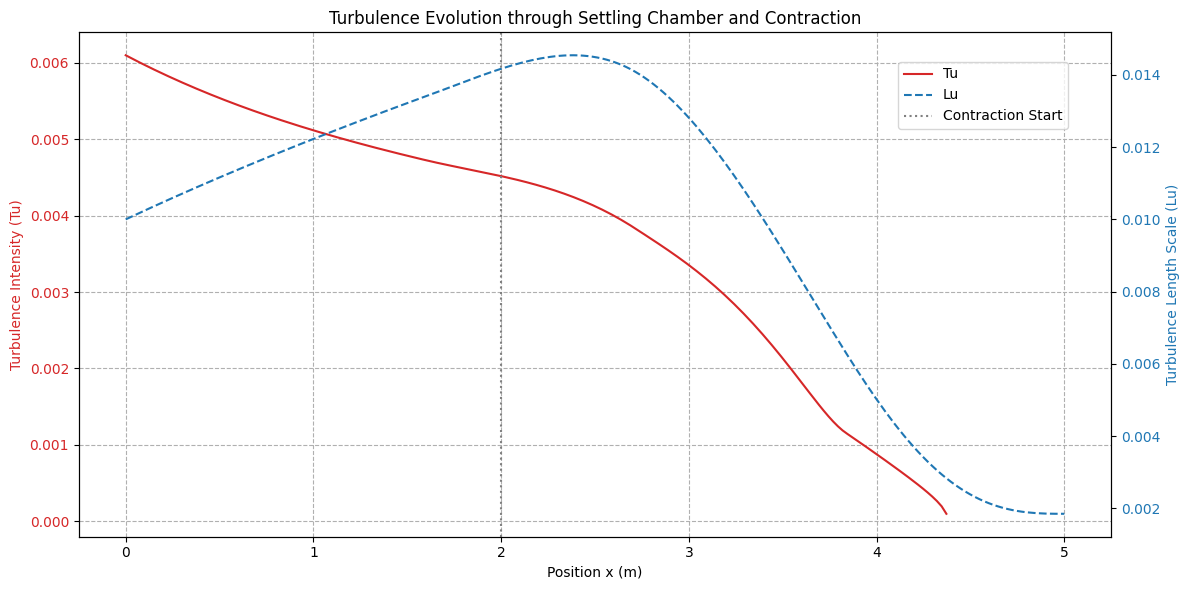

Initial Tu: 0.0061
Final Tu: nan
Initial Lu: 0.0100
Final Lu: 0.0019


In [4]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import numpy as np

def method2_honeycomb(Tu_in, Psi_ley=1.0):
    """
    Calculates turbulence intensity after honeycomb using Method 2.
    
    Args:
        Tu_in (float): Incoming turbulence intensity.
        Psi_ley (float): Ley's factor (default 1.0).
        
    Returns:
        float: Turbulence intensity after honeycomb.
    """
    return 1.3 * Tu_in * Psi_ley

def method2_screen(Tu_in, K):
    """
    Calculates turbulence intensity after a screen using Method 2.
    
    Args:
        Tu_in (float): Incoming turbulence intensity.
        K (float): Screen pressure loss coefficient.
        
    Returns:
        float: Turbulence intensity after screen.
    """
    return Tu_in / np.sqrt(1 + K)

def unobstructed_flow(x, y, U_func, dUdx_func, c1, c2):
    """
    Differential equations for turbulence in unobstructed flow.
    y[0] = Tu^2
    y[1] = L_u
    """
    Tu2, Lu = y
    if Tu2 < 0: # Prevent math domain error
        Tu2 = 0
    Tu = np.sqrt(Tu2)
    U = U_func(x)
    dUdx = dUdx_func(x)
    
    if Lu <= 0: # Avoid division by zero
        return [0, 0]

    dTu2_dx = -2 * c1 * Tu**3 / Lu - 2 * Tu2 / U * dUdx
    dLu_dx = c2 * Tu - Lu / U * dUdx
    
    return [dTu2_dx, dLu_dx]

# Define a more realistic velocity profile for a wind tunnel contraction
# using a 5th-order polynomial for a smooth transition.
L_settling = 2.0  # Length of the settling chamber (constant velocity)
L_contraction = 3.0 # Length of the contraction section
C = 10.0 # Contraction ratio

def U_profile(x):
    """ Velocity profile U(x) """
    U_in = 1.0
    if x <= L_settling:
        return U_in
    elif x > L_settling and x <= L_settling + L_contraction:
        # 5th order polynomial for smooth contraction
        s = (x - L_settling) / L_contraction
        A_ratio = 1.0 + (1.0/C - 1.0) * (10*s**3 - 15*s**4 + 6*s**5)
        return U_in / A_ratio
    else:
        return U_in * C

def dUdx_profile(x):
    """ Derivative of the velocity profile dU/dx """
    U_in = 1.0
    if x <= L_settling or x > L_settling + L_contraction:
        return 0.0
    else:
        s = (x - L_settling) / L_contraction
        # Derivative of A_ratio with respect to s
        dA_ds = (1.0/C - 1.0) * (30*s**2 - 60*s**3 + 30*s**4)
        # Chain rule: dU/dx = dU/dA * dA/ds * ds/dx
        ds_dx = 1.0 / L_contraction
        dU_dA = -U_in / ( (1.0 + (1.0/C - 1.0) * (10*s**3 - 15*s**4 + 6*s**5))**2 )
        return dU_dA * dA_ds * ds_dx

# Constants from turbulence theory
c1 = 0.35 
c2 = 0.4

# Initial conditions after the last screen (example values)
Tu_after_screens = 0.0061 # From Method 2, 5 screens result
Lu0 = 0.01 # Initial turbulence length scale (m), placeholder
y0 = [Tu_after_screens**2, Lu0]

# Span of integration (settling chamber + contraction)
x_span = [0, L_settling + L_contraction]
x_eval = np.linspace(x_span[0], x_span[1], 200)

# Solve the ODEs
sol = solve_ivp(
    fun=lambda x, y: unobstructed_flow(x, y, U_profile, dUdx_profile, c1, c2),
    t_span=x_span,
    y0=y0,
    t_eval=x_eval,
    method='RK45'
)

# Extract and plot results
Tu_solution = np.sqrt(sol.y[0])
Lu_solution = sol.y[1]

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Turbulence Intensity
color = 'tab:red'
ax1.set_xlabel('Position x (m)')
ax1.set_ylabel('Turbulence Intensity (Tu)', color=color)
ax1.plot(sol.t, Tu_solution, color=color, label='Tu')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, which="both", ls="--")
ax1.set_title('Turbulence Evolution through Settling Chamber and Contraction')

# Plot Turbulence Length Scale on a second y-axis
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Turbulence Length Scale (Lu)', color=color)
ax2.plot(sol.t, Lu_solution, color=color, linestyle='--', label='Lu')
ax2.tick_params(axis='y', labelcolor=color)

# Add a vertical line to show where contraction starts
plt.axvline(x=L_settling, color='gray', linestyle=':', label='Contraction Start')

fig.tight_layout()
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.show()

print(f"Initial Tu: {Tu_solution[0]:.4f}")
print(f"Final Tu: {Tu_solution[-1]:.4f}")
print(f"Initial Lu: {Lu_solution[0]:.4f}")
print(f"Final Lu: {Lu_solution[-1]:.4f}")


## 3 湍流度计算及试验比较分析

### 3.1 湍流度计算
针对该风洞，采用上述2种方法建立计算程序对气流从蜂窝器到试验段的湍流度变化情况进行了计算，**表 3** 给出了方法一在3层及5层阻尼网时的计算结果。

**表 3 方法一湍流度计算结果 (%)**

| 位置 | 阻尼网层数 | 纵向 | 横向 | 综合 |
| :--- | :--- | :--- | :--- | :--- |
| **蜂窝器入口** | 3 & 5 | 16.00 | 17.60 | 17.08 |
| **蜂窝器出口** | 3 & 5 | 6.16 | 6.78 | 6.59 |
| **第1层阻尼网出口** | 3 & 5 | 3.89 | 4.28 | 4.16 |
| **第2层阻尼网出口** | 3 & 5 | 2.46 | 2.71 | 2.63 |
| **第3层阻尼网出口** | 3 & 5 | 1.56 | 1.71 | 1.66 |
| **第4层阻尼网出口** | 5 | 0.98 | 1.08 | 1.05 |
| **第5层阻尼网出口** | 5 | 0.62 | 0.68 | 0.66 |
| **收缩段出口** | 3 | 0.17 | 0.19 | 0.18 |
| | 5 | 0.07 | 0.08 | 0.07 |

**表 4** 给出了方法二在3层及5层阻尼网时的计算结果。

**表 4 方法二湍流度计算结果 (%)**

| 位置 | 3层阻尼网 | 5层阻尼网 |
| :--- | :--- | :--- |
| 蜂窝器入口 | 16.00 | 16.00 |
| 蜂窝器出口 | 5.98 | 5.98 |
| 第1层阻尼网出口 | 3.78 | 3.78 |
| 第2层阻尼网出口 | 2.39 | 2.39 |
| 第3层阻尼网出口 | 1.51 | 1.51 |
| 第4层阻尼网出口 | | 0.96 |
| 第5层阻尼网出口 | | 0.61 |
| 收缩段出口 | 0.15 | 0.06 |

从计算结果可以看出，2种方法获得的气流湍流衰减变化趋势基本一致，湍流度衰减主要集中在前3层阻尼网，衰减约65%。

![图 4 2种方法计算结果对比](imgs/xbgydxxb-41-1-216-4.jpg)

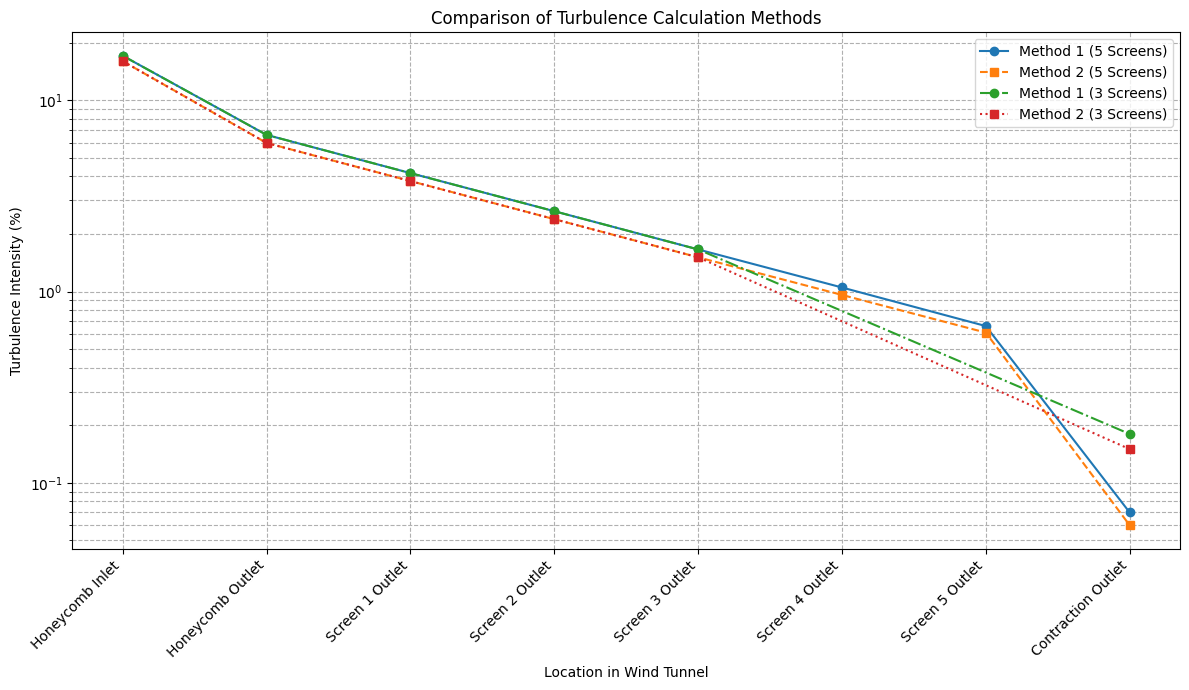

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Data from Table 3 and 4
data = {
    'Location': ['Honeycomb Inlet', 'Honeycomb Outlet', 'Screen 1 Outlet', 'Screen 2 Outlet', 'Screen 3 Outlet', 'Screen 4 Outlet', 'Screen 5 Outlet', 'Contraction Outlet'],
    'Method1_3_screens': [17.08, 6.59, 4.16, 2.63, 1.66, np.nan, np.nan, 0.18],
    'Method1_5_screens': [17.08, 6.59, 4.16, 2.63, 1.66, 1.05, 0.66, 0.07],
    'Method2_3_screens': [16.00, 5.98, 3.78, 2.39, 1.51, np.nan, np.nan, 0.15],
    'Method2_5_screens': [16.00, 5.98, 3.78, 2.39, 1.51, 0.96, 0.61, 0.06]
}

df = pd.DataFrame(data)

# Create a separate dataframe for the 3-screen data and drop rows with NaN
df_3_screens = df[['Location', 'Method1_3_screens', 'Method2_3_screens']].dropna().reset_index(drop=True)


# Plotting the results
plt.figure(figsize=(12, 7))

# Plot data for 5 screens (which has no missing values)
plt.plot(df['Location'], df['Method1_5_screens'], 'o-', label='Method 1 (5 Screens)')
plt.plot(df['Location'], df['Method2_5_screens'], 's--', label='Method 2 (5 Screens)')

# Plot data for 3 screens from the cleaned dataframe
plt.plot(df_3_screens['Location'], df_3_screens['Method1_3_screens'], 'o-.', label='Method 1 (3 Screens)')
plt.plot(df_3_screens['Location'], df_3_screens['Method2_3_screens'], 's:', label='Method 2 (3 Screens)')


plt.title('Comparison of Turbulence Calculation Methods')
plt.xlabel('Location in Wind Tunnel')
plt.ylabel('Turbulence Intensity (%)')
plt.xticks(rotation=45, ha='right')
plt.yscale('log')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.tight_layout()
plt.show()

### 3.2 试验结果
采用热线风速仪对该风洞试验段核心区的气流湍流度进行了测试，测试马赫数0.3~1.2，5层阻尼网状态，测试结果如 **图 5** 所示。

![图 5 试验段气流湍流度测试结果](imgs/xbgydxxb-41-1-216-5.jpg)

从测试结果可以看出，该风洞试验段气流湍流度在0.06%~0.11%之间，满足设计指标要求。将计算结果与试验结果进行对比，方法一计算结果(0.07%)较实测最大值(0.11%)偏小约36%，较实测最小值(0.06%)偏大约17%；方法二计算结果(0.06%)与实测最小值(0.06%)基本一致。虽然2种方法所得结果与实测值绝对值稍有偏差，但趋势及结果量级一致，可有效用于风洞整流装置优化设计。

### 3.3 阻尼网间距对气流湍流度影响分析
为进一步研究阻尼网设置对气流湍流度的影响，采用方法一分析了阻尼网间距对试验段气流湍流度的影响，计算结果如 **图 6** 所示。从图中可以看出，随着阻尼网间距的增加，试验段气流湍流度逐步降低，但降低的趋势逐步减缓。

![图 6 阻尼网间距对试验段气流湍流度影响](imgs/xbgydxxb-41-1-216-6.jpg)

**图 7** 给出了阻尼网压损对试验段气流湍流度的影响。从图中可以看出，随着阻尼网压损的增加，试验段气流湍流度也逐步降低，同样降低的趋势逐步减缓。

![图 7 阻尼网压损对试验段气流湍流度影响](imgs/xbgydxxb-41-1-216-7.jpg)

## 4 结论
本文针对0.6 m连续式跨声速风洞，采用2种方法对稳定段气流湍流度进行了计算，并与试验测试结果进行了对比分析，得到如下结论：
1) 2种方法获得的气流湍流衰减变化趋势基本一致，湍流度衰减主要集中在前3层阻尼网，衰减约65%。
2) 方法一计算结果较实测最大值偏小约36%，较实测最小值偏大约17%；方法二计算结果与实测最小值基本一致。2种方法所得结果与实测值绝对值稍有偏差，但趋势及结果量级一致，可有效用于风洞整流装置优化设计。
3) 随着阻尼网间距及压损的增加，试验段气流湍流度逐步降低，但降低的趋势逐步减缓。

## 参考文献
[1] GB/T 13333-2012, 风洞和发动机试验设备术语[S].

[2] 裴海涛, 陈吉明, 廖达雄, 等. 0.6m连续式跨声速风洞设计研究[J]. 气体物理, 2021, 6(6): 25-32.

[3] 白存儒. 湍流度对大攻角非定常流动的数值模拟[D]. 西安: 西北工业大学, 2001.

[4] 何克敏. 来流湍流度对翼型气动特性影响的数值研究[D]. 绵阳: 中国空气动力研究与发展中心, 2017.

[5] 王庶, 邓小刚, 符松. 来流湍流度对高超声速边界层转捩影响的数值模拟研究[J]. 空气动力学学报, 2018, 36(5): 733-740.

[6] GJB 1179A-2012, 飞行器模型风洞试验方法[S].

[7] AHMED R, EL-SAYED A, GOMAA A, et al. Influence of screen parameters on the flow uniformity and turbulence in the downstream of a wind tunnel[J]. Journal of Wind Engineering and Industrial Aerodynamics, 2018, 175: 234-245.

[8] MEHTA R D, BRADSHAW P. Design rules for low speed wind tunnels[J]. The Aeronautical Journal, 1979, 83(827): 443-449.

[9] BATCHELOR G K. The theory of homogeneous turbulence[M]. Cambridge: Cambridge University Press, 1953.